# Comparative Evaluation of Classifiers on UCI Datasets: A Cross-Validation Approach
### By: Michael Schaar

In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## Iris Dataset

In [2]:
# Preprocess Iris dataset 
# Define column names
column_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]

# Load the dataset
iris_df = pd.read_csv("iris.data", header=None, names=column_names)

# Display first few rows
print(iris_df.head())

   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [3]:
# Convert class column to binary (1 for "Iris-setosa", 0 for others)
iris_df["class"] = iris_df["class"].apply(lambda x: 1 if x == "Iris-setosa" else 0)

#View class distribution 
print(iris_df["class"].value_counts())

class
0    100
1     50
Name: count, dtype: int64


In [4]:
# Extract features (X) and target labels (y)
X = iris_df.iloc[:, :-1].values 
y = iris_df.iloc[:, -1].values  

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)  

# Shuffle the dataset before partitioning
iris_df = iris_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Define partitions and initialize storage
partitions = [(0.2, 0.8), (0.5, 0.5), (0.8, 0.2)]
partitioned_datasets = []

# Create splits for each partition and trial
for train_ratio, test_ratio in partitions:
    for trial in range(3):
        # Generate a unique random state for each trial and partition
        random_seed = trial + hash(f"{train_ratio}-{test_ratio}") % (2**32)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size = test_ratio, random_state = random_seed, shuffle = True
        )
        partitioned_datasets.append({
            'train_ratio': train_ratio,
            'test_ratio': test_ratio,
            'trial': trial,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test
        })
        print(f"Partition: {train_ratio}/{test_ratio}, Trial: {trial}, Train size: {len(X_train)}, Test size: {len(X_test)}")

Partition: 0.2/0.8, Trial: 0, Train size: 30, Test size: 120
Partition: 0.2/0.8, Trial: 1, Train size: 30, Test size: 120
Partition: 0.2/0.8, Trial: 2, Train size: 30, Test size: 120
Partition: 0.5/0.5, Trial: 0, Train size: 75, Test size: 75
Partition: 0.5/0.5, Trial: 1, Train size: 75, Test size: 75
Partition: 0.5/0.5, Trial: 2, Train size: 75, Test size: 75
Partition: 0.8/0.2, Trial: 0, Train size: 120, Test size: 30
Partition: 0.8/0.2, Trial: 1, Train size: 120, Test size: 30
Partition: 0.8/0.2, Trial: 2, Train size: 120, Test size: 30


In [5]:
# Verify that train and test sets are disjoint
for dataset in partitioned_datasets:
    X_train = dataset['X_train']
    X_test = dataset['X_test']
    trial = dataset['trial']
    train_ratio = dataset['train_ratio']
    test_ratio = dataset['test_ratio']

    # Check for overlap
    overlap = set(map(tuple, X_train)).intersection(set(map(tuple, X_test)))

    if overlap:
        print(f"Overlap detected in Partition {train_ratio}/{test_ratio}, Trial {trial}.")
    else:
        print(f"No overlap in Partition {train_ratio}/{test_ratio}, Trial {trial}.")

No overlap in Partition 0.2/0.8, Trial 0.
Overlap detected in Partition 0.2/0.8, Trial 1.
No overlap in Partition 0.2/0.8, Trial 2.
Overlap detected in Partition 0.5/0.5, Trial 0.
Overlap detected in Partition 0.5/0.5, Trial 1.
Overlap detected in Partition 0.5/0.5, Trial 2.
Overlap detected in Partition 0.8/0.2, Trial 0.
Overlap detected in Partition 0.8/0.2, Trial 1.
No overlap in Partition 0.8/0.2, Trial 2.


## Logistic Regression Classifier (Iris)

In [6]:
# Logistic regression with 5-fold cross-validation
# Store results
logistic_results = []

# Define hyperparameter grid
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Loop through partitions and trials
for dataset in partitioned_datasets:
    train_ratio = dataset['train_ratio']
    test_ratio = dataset['test_ratio']
    trial = dataset['trial']
    X_train = dataset['X_train']
    X_test = dataset['X_test']
    y_train = dataset['y_train']
    y_test = dataset['y_test'] 

    # Set up Logistic Regression with GridSearchCV
    clf = GridSearchCV(
        estimator = LogisticRegression(max_iter = 1000, random_state = 42),
        param_grid = param_grid,
        cv = 5,  # 5-fold cross-validation
        scoring = 'accuracy'
    )
    
    # Train model with cross-validation
    clf.fit(X_train, y_train)
    best_model = clf.best_estimator_

    # Evaluate on training and test sets
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Save results
    logistic_results.append({
        'train_ratio': train_ratio,
        'test_ratio': test_ratio,
        'trial': trial,
        'best_hyperparameter': clf.best_params_['C'],
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })
    
    # Print results for this split
    print(f"Partition: {train_ratio}/{test_ratio}, Trial: {trial}, "
          f"Best C: {clf.best_params_['C']}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 0.2/0.8, Trial: 0, Best C: 0.1, Train Accuracy: 1.00, Test Accuracy: 0.99
Partition: 0.2/0.8, Trial: 1, Best C: 0.1, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.2/0.8, Trial: 2, Best C: 1, Train Accuracy: 1.00, Test Accuracy: 0.99
Partition: 0.5/0.5, Trial: 0, Best C: 0.1, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.5/0.5, Trial: 1, Best C: 0.1, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.5/0.5, Trial: 2, Best C: 0.1, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.8/0.2, Trial: 0, Best C: 0.1, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.8/0.2, Trial: 1, Best C: 0.1, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.8/0.2, Trial: 2, Best C: 0.01, Train Accuracy: 1.00, Test Accuracy: 0.97


In [7]:
# Convert results to a DataFrame
log_results_df = pd.DataFrame(logistic_results)
print(log_results_df)

   train_ratio  test_ratio  trial  best_hyperparameter  train_accuracy  \
0          0.2         0.8      0                 0.10             1.0   
1          0.2         0.8      1                 0.10             1.0   
2          0.2         0.8      2                 1.00             1.0   
3          0.5         0.5      0                 0.10             1.0   
4          0.5         0.5      1                 0.10             1.0   
5          0.5         0.5      2                 0.10             1.0   
6          0.8         0.2      0                 0.10             1.0   
7          0.8         0.2      1                 0.10             1.0   
8          0.8         0.2      2                 0.01             1.0   

   test_accuracy  
0       0.991667  
1       1.000000  
2       0.991667  
3       1.000000  
4       1.000000  
5       1.000000  
6       1.000000  
7       1.000000  
8       0.966667  


In [8]:
# Calculate average accuracies for each partition
avg_log_results = log_results_df.groupby(['train_ratio', 'test_ratio'])[['train_accuracy', 'test_accuracy']].mean()
print(avg_log_results)

                        train_accuracy  test_accuracy
train_ratio test_ratio                               
0.2         0.8                    1.0       0.994444
0.5         0.5                    1.0       1.000000
0.8         0.2                    1.0       0.988889


## Support Vector Machine (SVM) Classifier (Iris)

In [9]:
# SVM with 5-fold cross-validation
# Store results
svm_results = []

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']  # Applicable for non-linear kernels
}

# Loop through partitions and trials
for dataset in partitioned_datasets:
    train_ratio = dataset['train_ratio']
    test_ratio = dataset['test_ratio']
    trial = dataset['trial']
    X_train = dataset['X_train']
    X_test = dataset['X_test']
    y_train = dataset['y_train']
    y_test = dataset['y_test']

    # Set up SVM with GridSearchCV
    clf = GridSearchCV(
        estimator = SVC(),
        param_grid = param_grid,
        cv = 5,
        scoring = 'accuracy',
    )

    # Train model with cross-validation
    clf.fit(X_train, y_train)
    best_model = clf.best_estimator_

    # Evaluate on training and test sets
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Save results
    svm_results.append({
        'train_ratio': train_ratio,
        'test_ratio': test_ratio,
        'trial': trial,
        'best_hyperparameters': clf.best_params_,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

    # Print results for this split
    print(f"Partition: {train_ratio}/{test_ratio}, Trial: {trial}, "
          f"Best Params: {clf.best_params_}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 0.2/0.8, Trial: 0, Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 1.00, Test Accuracy: 0.99
Partition: 0.2/0.8, Trial: 1, Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.2/0.8, Trial: 2, Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 1.00, Test Accuracy: 0.99
Partition: 0.5/0.5, Trial: 0, Best Params: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.5/0.5, Trial: 1, Best Params: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.5/0.5, Trial: 2, Best Params: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 1.00, Test Accuracy: 0.99
Partition: 0.8/0.2, Trial: 0, Best Params: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.8/0.2, Trial: 1, Best Params: {'C': 0.

In [10]:
# Convert results to a DataFrame
svm_results_df = pd.DataFrame(svm_results)
print(svm_results_df)

   train_ratio  test_ratio  trial  \
0          0.2         0.8      0   
1          0.2         0.8      1   
2          0.2         0.8      2   
3          0.5         0.5      0   
4          0.5         0.5      1   
5          0.5         0.5      2   
6          0.8         0.2      0   
7          0.8         0.2      1   
8          0.8         0.2      2   

                                best_hyperparameters  train_accuracy  \
0   {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}             1.0   
1   {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}             1.0   
2   {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}             1.0   
3  {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}             1.0   
4  {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}             1.0   
5  {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}             1.0   
6  {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}             1.0   
7  {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'} 

In [11]:
# Calculate average accuracies for each partition
avg_svm_results = svm_results_df.groupby(['train_ratio', 'test_ratio'])[['train_accuracy', 'test_accuracy']].mean()
print(avg_svm_results)

                        train_accuracy  test_accuracy
train_ratio test_ratio                               
0.2         0.8                    1.0       0.994444
0.5         0.5                    1.0       0.995556
0.8         0.2                    1.0       1.000000


## Random Forest Classifier (Iris)

In [12]:
# Random forest with 5-fold cross-validation
# Store results 
rf_results = []

# Define hyperparameter grid
rf_param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20, 30],
    'criterion': ['gini', 'entropy']
}

# Loop through partitions and trials
for dataset in partitioned_datasets:
    train_ratio = dataset['train_ratio']
    test_ratio = dataset['test_ratio']
    trial = dataset['trial']
    X_train = dataset['X_train']
    X_test = dataset['X_test']
    y_train = dataset['y_train']
    y_test = dataset['y_test']

    # Set up Random Forest with GridSearchCV
    clf = GridSearchCV(
        estimator = RandomForestClassifier(random_state=42),
        param_grid = rf_param_grid,
        cv = 5, 
        scoring = 'accuracy'
    )

    # Train model with cross-validation
    clf.fit(X_train, y_train)
    best_model = clf.best_estimator_

    # Evaluate on training and test sets
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Save results
    rf_results.append({
        'train_ratio': train_ratio,
        'test_ratio': test_ratio,
        'trial': trial,
        'best_hyperparameters': clf.best_params_,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

    # Print results for this split
    print(f"Partition: {train_ratio}/{test_ratio}, Trial: {trial}, "
          f"Best Params: {clf.best_params_}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 0.2/0.8, Trial: 0, Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.2/0.8, Trial: 1, Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.2/0.8, Trial: 2, Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.5/0.5, Trial: 0, Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.5/0.5, Trial: 1, Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.5/0.5, Trial: 2, Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}, Train Accuracy: 1.00, Test Accuracy: 1.00
Partition: 0.8/0.2, Trial: 0, Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}, Train Accurac

In [13]:
# Convert results to a DataFrame
rf_results_df = pd.DataFrame(rf_results)
print(rf_results_df)

   train_ratio  test_ratio  trial  \
0          0.2         0.8      0   
1          0.2         0.8      1   
2          0.2         0.8      2   
3          0.5         0.5      0   
4          0.5         0.5      1   
5          0.5         0.5      2   
6          0.8         0.2      0   
7          0.8         0.2      1   
8          0.8         0.2      2   

                                best_hyperparameters  train_accuracy  \
0  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
1  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
2  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
3  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
4  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
5  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
6  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
7  {'criterion': 'gini', 'max_depth': None, 'n_es... 

In [14]:
# Calculate average accuracies for each partition
avg_rf_results = rf_results_df.groupby(['train_ratio', 'test_ratio'])[['train_accuracy', 'test_accuracy']].mean()
print(avg_rf_results)

                        train_accuracy  test_accuracy
train_ratio test_ratio                               
0.2         0.8                    1.0            1.0
0.5         0.5                    1.0            1.0
0.8         0.2                    1.0            1.0


## Test Accuracy Comparison: Random Forest vs. SVM vs. Logistic Regression on the Iris Dataset

In [15]:
# Collect best accuracies for each model
rf_best_accuracy = rf_results_df['test_accuracy'].max()  # Random Forest max accuracy
svm_best_accuracy = svm_results_df['test_accuracy'].max()  # SVM max accuracy
logistic_best_accuracy = log_results_df['test_accuracy'].max()

# Create a comparison DataFrame
results_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Logistic Regression'],
    'Best Test Accuracy': [rf_best_accuracy, svm_best_accuracy, logistic_best_accuracy]
})

print(results_comparison)


                 Model  Best Test Accuracy
0        Random Forest                 1.0
1                  SVM                 1.0
2  Logistic Regression                 1.0


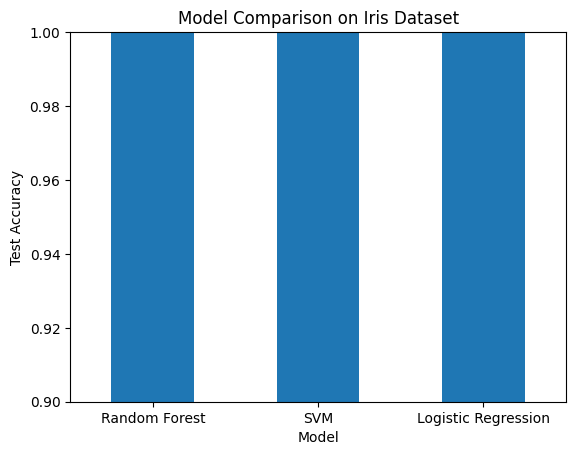

In [16]:
results_comparison.plot(kind = 'bar', x = 'Model', y = 'Best Test Accuracy', legend = False)
plt.title('Model Comparison on Iris Dataset')
plt.ylabel('Test Accuracy')
plt.xticks(rotation = 0)
plt.ylim(0.9, 1.0)  
plt.show()

## Random Forest Hyperparameter Heatmap for Iris Dataset

In [17]:
# Extract param_max_depth and param_n_estimators columns
rf_results_df['param_max_depth'] = rf_results_df['best_hyperparameters'].apply(lambda x: x['max_depth'])
rf_results_df['param_n_estimators'] = rf_results_df['best_hyperparameters'].apply(lambda x: x['n_estimators'])

print(rf_results_df.head())
print(rf_results_df.columns)

   train_ratio  test_ratio  trial  \
0          0.2         0.8      0   
1          0.2         0.8      1   
2          0.2         0.8      2   
3          0.5         0.5      0   
4          0.5         0.5      1   

                                best_hyperparameters  train_accuracy  \
0  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
1  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
2  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
3  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
4  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   

   test_accuracy param_max_depth  param_n_estimators  
0            1.0            None                  50  
1            1.0            None                  10  
2            1.0            None                  50  
3            1.0            None                  10  
4            1.0            None                  10  
Index(['train_

In [18]:
# Handle "None" values in param_max_depth
rf_results_df['param_max_depth'] = rf_results_df['param_max_depth'].apply(lambda x: "No Limit" if x is None else x)
                                                                         
print(rf_results_df.head())

   train_ratio  test_ratio  trial  \
0          0.2         0.8      0   
1          0.2         0.8      1   
2          0.2         0.8      2   
3          0.5         0.5      0   
4          0.5         0.5      1   

                                best_hyperparameters  train_accuracy  \
0  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
1  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
2  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
3  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   
4  {'criterion': 'gini', 'max_depth': None, 'n_es...             1.0   

   test_accuracy param_max_depth  param_n_estimators  
0            1.0        No Limit                  50  
1            1.0        No Limit                  10  
2            1.0        No Limit                  50  
3            1.0        No Limit                  10  
4            1.0        No Limit                  10  


In [19]:
# Group and pivot data
heatmap_data_rf = (
    rf_results_df.groupby(['param_max_depth', 'param_n_estimators'], as_index = False)
    .agg({'test_accuracy': 'mean'})
    .pivot(index = 'param_max_depth', columns = 'param_n_estimators', values = 'test_accuracy')
)

print(heatmap_data_rf)

param_n_estimators   10   50
param_max_depth             
No Limit            1.0  1.0


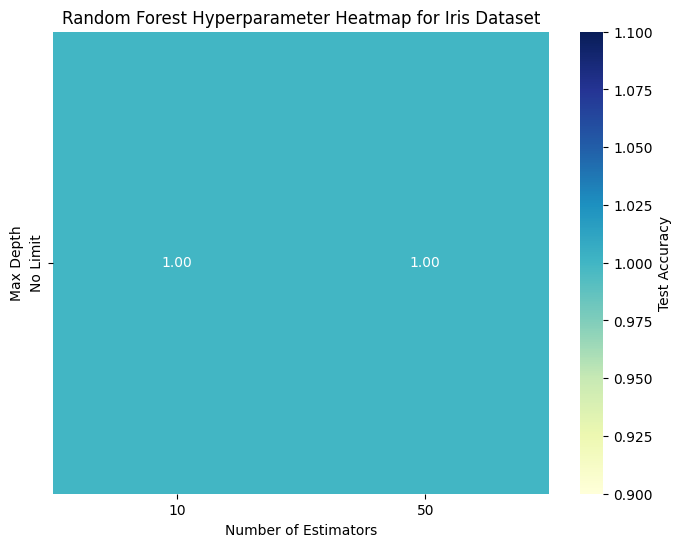

In [20]:
# Plot the heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(
    heatmap_data_rf,
    annot = True, 
    fmt = ".2f",   
    cmap = "YlGnBu",  
    cbar_kws = {'label': 'Test Accuracy'}  
)
plt.title("Random Forest Hyperparameter Heatmap for Iris Dataset")
plt.xlabel("Number of Estimators")
plt.ylabel("Max Depth")
plt.show()

## Breast Cancer Wisconsin Dataset

In [21]:
# Preprocess Breast Cancer Wisconsin dataset 
# Define column names
column_names = [
    "ID", "Diagnosis", 
    "Radius1", "Texture1", "Perimeter1", "Area1", "Smoothness1",
    "Compactness1", "Concavity1", "Concave_Points1", "Symmetry1", "Fractal_Dimension1",
    "Radius2", "Texture2", "Perimeter2", "Area2", "Smoothness2",
    "Compactness2", "Concavity2", "Concave_Points2", "Symmetry2", "Fractal_Dimension2",
    "Radius3", "Texture3", "Perimeter3", "Area3", "Smoothness3",
    "Compactness3", "Concavity3", "Concave_Points3", "Symmetry3", "Fractal_Dimension3"
]

# Load the dataset
cancer_df = pd.read_csv("wdbc.data", header = None, names = column_names)

# Display first few rows
print(cancer_df.head())

         ID Diagnosis  Radius1  Texture1  Perimeter1   Area1  Smoothness1  \
0    842302         M    17.99     10.38      122.80  1001.0      0.11840   
1    842517         M    20.57     17.77      132.90  1326.0      0.08474   
2  84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3  84348301         M    11.42     20.38       77.58   386.1      0.14250   
4  84358402         M    20.29     14.34      135.10  1297.0      0.10030   

   Compactness1  Concavity1  Concave_Points1  ...  Radius3  Texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   Perimeter3   Area3  Smoothness3  Compactness3  Concavity3  Concave_Points3  \
0      184.60  2019.0  

In [22]:
# Check dataset info
print(cancer_df.info())

# Summary stats
print(cancer_df.describe())

# Check for missing values
print(cancer_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   Diagnosis           569 non-null    object 
 2   Radius1             569 non-null    float64
 3   Texture1            569 non-null    float64
 4   Perimeter1          569 non-null    float64
 5   Area1               569 non-null    float64
 6   Smoothness1         569 non-null    float64
 7   Compactness1        569 non-null    float64
 8   Concavity1          569 non-null    float64
 9   Concave_Points1     569 non-null    float64
 10  Symmetry1           569 non-null    float64
 11  Fractal_Dimension1  569 non-null    float64
 12  Radius2             569 non-null    float64
 13  Texture2            569 non-null    float64
 14  Perimeter2          569 non-null    float64
 15  Area2               569 non-null    float64
 16  Smoothne

In [23]:
# Drop unnecessary  columns 
cancer_df = cancer_df.drop(columns = ["ID"])

# Convert target labels to binary values
cancer_df["Diagnosis"] = cancer_df["Diagnosis"].map({"M": 1, "B": 0})

# Separate features and target
X = cancer_df.drop(columns = ["Diagnosis"])
y = cancer_df["Diagnosis"]

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X = pd.DataFrame(X_normalized, columns = X.columns)

# Partition the dataset (20/80, 50/50, 80/20)
partitions = {}
partition_ratios = {
    "20/80": 0.80,
    "50/50": 0.50,
    "80/20": 0.20
}

for name, test_size in partition_ratios.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = test_size, random_state = 42, stratify = y
    )
    partitions[name] = (X_train, X_test, y_train, y_test)

# Preview partitions
for partition, (X_train, X_test, y_train, y_test) in partitions.items():
    print(f"Partition: {partition}")
    print(f"  Training samples: {len(X_train)}")
    print(f"  Testing samples: {len(X_test)}")
    print(f"  Training data preview:\n{X_train.head()}")
    print(f"  Testing data preview:\n{X_test.head()}")

Partition: 20/80
  Training samples: 113
  Testing samples: 456
  Training data preview:
      Radius1  Texture1  Perimeter1     Area1  Smoothness1  Compactness1  \
293 -0.646783 -0.425771   -0.676715 -0.631929    -0.899551     -0.908174   
97  -1.232704  0.151341   -1.229900 -1.024984     0.429819     -0.972798   
465 -0.252003  0.195555   -0.210030 -0.318509    -0.962177      0.340350   
163 -0.507616  0.681912   -0.499185 -0.541486     0.344421     -0.053841   
414  0.284783  2.448156    0.195281  0.183760    -0.936557     -1.104700   

     Concavity1  Concave_Points1  Symmetry1  Fractal_Dimension1  ...  \
293   -0.777395        -0.673717   0.231402           -0.800607  ...   
97    -1.029135        -1.057093  -1.685343            0.865077  ...   
465    0.153179        -0.531076  -0.768957            0.215815  ...   
163   -0.440671        -0.533913  -0.951504            0.682206  ...   
414   -0.526547        -0.555322   0.147430           -1.397419  ...   

      Radius3  Textur

## Logistic Regression Classifier (Cancer)

In [24]:
# Logistic regression with 5-fold cross-validation
# Store results
logistic_results_2 = []

# Define hyperparameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],  
    "penalty": ["l2"],  
    "solver": ["lbfgs", "saga"]  
}

# Loop through each partition and trial
for partition_name, (X_train, X_test, y_train, y_test) in partitions.items():
    for trial in range(3):  
        print(f"Partition: {partition_name}, Trial: {trial + 1}")

        # Set up Logistic Regression with GridSearchCV
        clf = GridSearchCV(
            estimator = LogisticRegression(max_iter = 10000),
            param_grid = param_grid,
            cv = 5, 
            scoring = "accuracy"
        )

        # Train model
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_

        # Predict and calculate accuracy
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        # Save results
        logistic_results_2.append({
            "partition": partition_name,
            "trial": trial,
            "best_hyperparameters": clf.best_params_,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

        # Print results for this trial
        print(f"Best Params: {clf.best_params_}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 20/80, Trial: 1
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}, Train Accuracy: 1.00, Test Accuracy: 0.96
Partition: 20/80, Trial: 2
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}, Train Accuracy: 1.00, Test Accuracy: 0.96
Partition: 20/80, Trial: 3
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}, Train Accuracy: 1.00, Test Accuracy: 0.96
Partition: 50/50, Trial: 1
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}, Train Accuracy: 0.99, Test Accuracy: 0.97
Partition: 50/50, Trial: 2
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}, Train Accuracy: 0.99, Test Accuracy: 0.97
Partition: 50/50, Trial: 3
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}, Train Accuracy: 0.99, Test Accuracy: 0.97
Partition: 80/20, Trial: 1
Best Params: {'C': 100, 'penalty': 'l2', 'solver': 'saga'}, Train Accuracy: 0.99, Test Accuracy: 0.97
Partition: 80/20, Trial: 2
Best Params: {'C': 100, 'penalty': 'l2', 'solver': 'saga'}, Train Accurac

In [25]:
# Convert results to a DataFrame
logistic_results_2_df = pd.DataFrame(logistic_results_2)
print(logistic_results_2_df.head())

  partition  trial                           best_hyperparameters  \
0     20/80      0  {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}   
1     20/80      1  {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}   
2     20/80      2  {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}   
3     50/50      0   {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}   
4     50/50      1   {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}   

   train_accuracy  test_accuracy  
0        1.000000       0.962719  
1        1.000000       0.962719  
2        1.000000       0.962719  
3        0.989437       0.971930  
4        0.989437       0.971930  


In [26]:
# Calculate average accuracies for each partition
avg_log_2_results = logistic_results_2_df.groupby(['partition'])[['train_accuracy', 'test_accuracy']].mean()
print(avg_log_2_results)

           train_accuracy  test_accuracy
partition                               
20/80            1.000000       0.962719
50/50            0.989437       0.971930
80/20            0.989011       0.973684


## SVM Classifier (Cancer)

In [27]:
# SVM with 5-fold cross-validation
# Store results
svm_2_results = []

# Define hyperparameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],           
    "kernel": ["linear", "rbf"],            
    "gamma": ["scale", "auto"]              
}

# Loop through each partition and trial
for partition_name, (X_train, X_test, y_train, y_test) in partitions.items():
    for trial in range(3):  
        print(f"Partition: {partition_name}, Trial: {trial + 1}")

        # Set up SVM with GridSearchCV
        clf = GridSearchCV(
            estimator = SVC(),               
            param_grid = param_grid,         
            cv = 5,                          
            scoring = "accuracy"             
        )

        # Train model
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_

        # Predict and calculate accuracy
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        # Save results
        svm_2_results.append({
            "partition": partition_name,
            "trial": trial + 1,
            "best_hyperparameters": clf.best_params_,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

        # Print results for this trial
        print(f"Best Params: {clf.best_params_}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 20/80, Trial: 1
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, Train Accuracy: 1.00, Test Accuracy: 0.97
Partition: 20/80, Trial: 2
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, Train Accuracy: 1.00, Test Accuracy: 0.97
Partition: 20/80, Trial: 3
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, Train Accuracy: 1.00, Test Accuracy: 0.97
Partition: 50/50, Trial: 1
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 0.98, Test Accuracy: 0.98
Partition: 50/50, Trial: 2
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 0.98, Test Accuracy: 0.98
Partition: 50/50, Trial: 3
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}, Train Accuracy: 0.98, Test Accuracy: 0.98
Partition: 80/20, Trial: 1
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}, Train Accuracy: 0.99, Test Accuracy: 0.97
Partition: 80/20, Trial: 2
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}, Train Ac

In [28]:
# Convert results to a DataFrame
svm_2_results_df = pd.DataFrame(svm_2_results)
print(svm_2_results_df)

  partition  trial                              best_hyperparameters  \
0     20/80      1      {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}   
1     20/80      2      {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}   
2     20/80      3      {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}   
3     50/50      1  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}   
4     50/50      2  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}   
5     50/50      3  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}   
6     80/20      1       {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}   
7     80/20      2       {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}   
8     80/20      3       {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}   

   train_accuracy  test_accuracy  
0        1.000000       0.969298  
1        1.000000       0.969298  
2        1.000000       0.969298  
3        0.982394       0.978947  
4        0.982394       0.978947  
5        0.982394       0.978947  
6        0.986813       0.973684  

In [29]:
# Calculate average accuracies for each partition
svm_2_avg_results = svm_2_results_df.groupby(["partition"])[["train_accuracy", "test_accuracy"]].mean()
print(svm_2_avg_results)

           train_accuracy  test_accuracy
partition                               
20/80            1.000000       0.969298
50/50            0.982394       0.978947
80/20            0.986813       0.973684


## Random Forest Classifier (Cancer)

In [30]:
# Random forest with 5-fold cross-validation
# Store results
rf_2_results = []

# Define hyperparameter grid
rf_param_grid = {
    "n_estimators": [10, 50, 100],  
    "max_depth": [None, 10, 20],   
    "criterion": ["gini", "entropy"] 
}

# Loop through each partition and trial
for partition_name, (X_train, X_test, y_train, y_test) in partitions.items():
    for trial in range(3):
        print(f"Partition: {partition_name}, Trial: {trial + 1}")
        
        # Set up Random Forest with GridSearchCV
        clf = GridSearchCV(
            estimator = RandomForestClassifier(random_state = 42),
            param_grid = rf_param_grid,
            cv = 5,
            scoring = "accuracy"
        )
        
        # Train the model
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        
        # Predict and calculate accuracy
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        # Save results
        rf_2_results.append({
            "partition": partition_name,
            "trial": trial + 1,
            "best_hyperparameters": clf.best_params_,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })
        
        # Print results for this trial
        print(f"Best Params: {clf.best_params_}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 20/80, Trial: 1
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}, Train Accuracy: 1.00, Test Accuracy: 0.93
Partition: 20/80, Trial: 2
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}, Train Accuracy: 1.00, Test Accuracy: 0.93
Partition: 20/80, Trial: 3
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}, Train Accuracy: 1.00, Test Accuracy: 0.93
Partition: 50/50, Trial: 1
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}, Train Accuracy: 1.00, Test Accuracy: 0.96
Partition: 50/50, Trial: 2
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}, Train Accuracy: 1.00, Test Accuracy: 0.96
Partition: 50/50, Trial: 3
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}, Train Accuracy: 1.00, Test Accuracy: 0.96
Partition: 80/20, Trial: 1
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}, Train Accuracy: 1.00, Test Accurac

In [31]:
# Convert results to a DataFrame
rf_2_results_df = pd.DataFrame(rf_2_results)
print(rf_2_results_df)

  partition  trial                               best_hyperparameters  \
0     20/80      1  {'criterion': 'gini', 'max_depth': None, 'n_es...   
1     20/80      2  {'criterion': 'gini', 'max_depth': None, 'n_es...   
2     20/80      3  {'criterion': 'gini', 'max_depth': None, 'n_es...   
3     50/50      1  {'criterion': 'gini', 'max_depth': None, 'n_es...   
4     50/50      2  {'criterion': 'gini', 'max_depth': None, 'n_es...   
5     50/50      3  {'criterion': 'gini', 'max_depth': None, 'n_es...   
6     80/20      1  {'criterion': 'gini', 'max_depth': None, 'n_es...   
7     80/20      2  {'criterion': 'gini', 'max_depth': None, 'n_es...   
8     80/20      3  {'criterion': 'gini', 'max_depth': None, 'n_es...   

   train_accuracy  test_accuracy  
0             1.0       0.929825  
1             1.0       0.929825  
2             1.0       0.929825  
3             1.0       0.961404  
4             1.0       0.961404  
5             1.0       0.961404  
6             1.0       

In [32]:
# Calculate average accuracies for each partition
rf_2_avg_results = rf_2_results_df.groupby(["partition"])[["train_accuracy", "test_accuracy"]].mean()
print(rf_2_avg_results)

           train_accuracy  test_accuracy
partition                               
20/80                 1.0       0.929825
50/50                 1.0       0.961404
80/20                 1.0       0.973684


## Test Accuracy Comparison: Random Forest vs. SVM vs. Logistic Regression on the Breast Cancer Dataset

In [33]:
# Collect best accuracies for each classifier
logistic_results_2_best_accuracy = max(logistic_results_2_df['test_accuracy'])
svm_2_best_accuracy = max(svm_2_results_df['test_accuracy'])
rf_2_best_accuracy = max(rf_2_results_df['test_accuracy'])

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Random Forest'],
    'Best Test Accuracy': [logistic_results_2_best_accuracy, svm_2_best_accuracy, rf_2_best_accuracy]
})

# Display the DataFrame
print(comparison_df)

                 Model  Best Test Accuracy
0  Logistic Regression            0.973684
1                  SVM            0.978947
2        Random Forest            0.973684


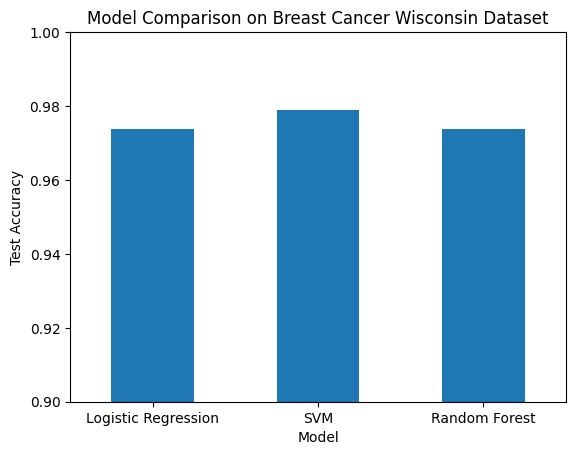

In [34]:
# Plot comparison
comparison_df.plot(kind = 'bar', x = 'Model', y = 'Best Test Accuracy', legend = False)
plt.title('Model Comparison on Breast Cancer Wisconsin Dataset')
plt.ylabel('Test Accuracy')
plt.xticks(rotation = 0)
plt.ylim(0.9, 1.0)  # Adjust the range for better clarity if needed
plt.show()

## Random Forest Feature Importance Heatmap for Breast Cancer Wisconsin Dataset

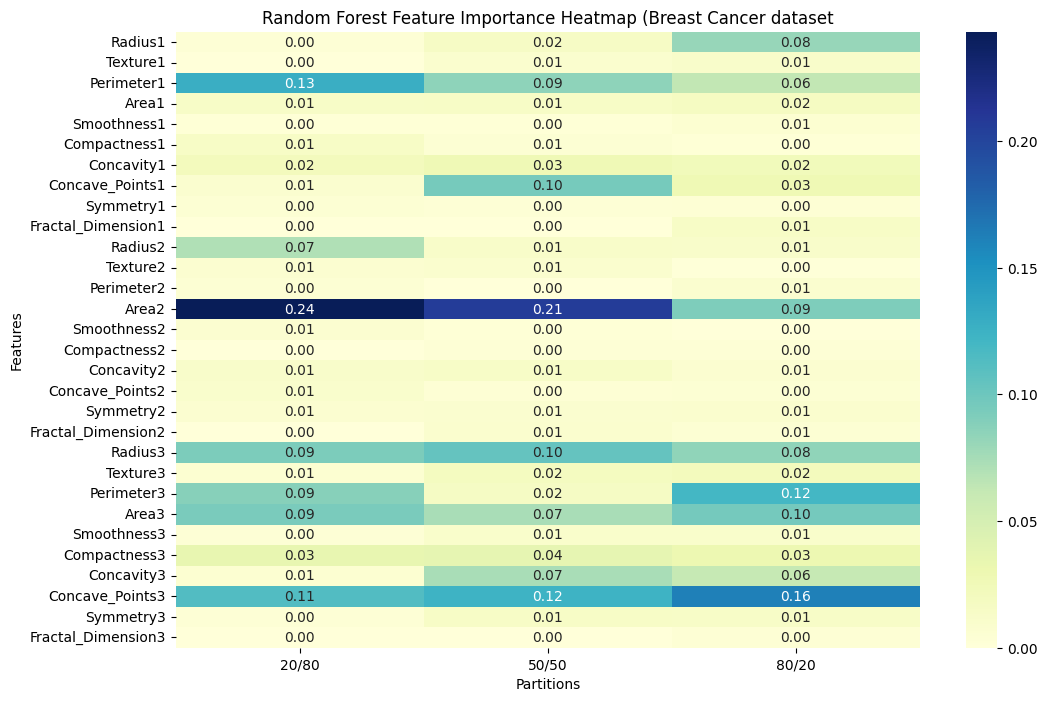

In [35]:
# Initialize dictionary to store feature importances
feature_importances = {partition: [] for partition in partitions.keys()}

# Collect feature importances for each trial in each partition
for partition_name, (X_train, X_test, y_train, y_test) in partitions.items():
    for trial in range(3):
        # Train a Random Forest model with the best parameters
        rf = RandomForestClassifier(n_estimators = 10, criterion = 'gini', max_depth = None, random_state = 42)
        rf.fit(X_train, y_train)

        # Append the feature importances
        feature_importances[partition_name].append(rf.feature_importances_)

# Average the feature importances across trials for each partition
avg_feature_importances = {
    partition: np.mean(importances, axis = 0)
    for partition, importances in feature_importances.items()
}

# Convert the results into a DataFrame for heatmap visualization
feature_importance_df = pd.DataFrame(avg_feature_importances, index = X_train.columns)

# Plot the heatmap
plt.figure(figsize = (12, 8))
sns.heatmap(feature_importance_df, annot = True, cmap = "YlGnBu", fmt = ".2f")
plt.title("Random Forest Feature Importance Heatmap (Breast Cancer dataset")
plt.xlabel("Partitions")
plt.ylabel("Features")
plt.show()

## Wine Quality Dataset

In [36]:
# Preprocess Wine Quality dataset 
# Load red and white wine datasets
red_wine = pd.read_csv("winequality-red.csv", sep = ";")
white_wine = pd.read_csv("winequality-white.csv", sep = ";")

# Display the first few rows of each dataset
print("Red Wine Dataset:")
print(red_wine.head())
print("\nWhite Wine Dataset:")
print(white_wine.head())

Red Wine Dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2 

In [37]:
# Add column 'WineType' to distinguish red (0) from white (1) wines
red_wine["WineType"] = 0
white_wine["WineType"] = 1

# Combine the datasets
combined_wine = pd.concat([red_wine, white_wine], axis = 0, ignore_index = True)

# Display the combined dataset
print("Combined Wine Dataset:")
print(combined_wine.head())

Combined Wine Dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  WineType  
0      9.4        5         0  

In [38]:
# Check for missing values
print("Missing values per column:")
print(combined_wine.isnull().sum())

# Check data types and summary stats
print("\nDataset Info:")
print(combined_wine.info())

print("\nSummary Statistics:")
print(combined_wine.describe())

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
WineType                0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null 

In [39]:
# Separate features and target
X = combined_wine.drop(columns = ["quality"])
y = combined_wine["quality"]

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X = pd.DataFrame(X_normalized, columns = X.columns)

# Preview normalized features
print("Normalized Features:")
print(X.head())

Normalized Features:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       0.142473          2.188833    -2.192833       -0.744778   0.569958   
1       0.451036          3.282235    -2.192833       -0.597640   1.197975   
2       0.451036          2.553300    -1.917553       -0.660699   1.026697   
3       3.073817         -0.362438     1.661085       -0.744778   0.541412   
4       0.142473          2.188833    -2.192833       -0.744778   0.569958   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -1.100140             -1.446359  1.034993  1.813090   0.193097   
1            -0.311320             -0.862469  0.701486 -0.115073   0.999579   
2            -0.874763             -1.092486  0.768188  0.258120   0.797958   
3            -0.762074             -0.986324  1.101694 -0.363868   0.327510   
4            -1.100140             -1.446359  1.034993  1.813090   0.193097   

    alcohol  WineType  
0 -0.915464

In [40]:
# Create partitions (20/80, 50/50, 80/20)
partitions = {}
partition_ratios = {"20/80": 0.80, "50/50": 0.50, "80/20": 0.20}

for name, test_size in partition_ratios.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, random_state = 42, stratify = y)
    partitions[name] = (X_train, X_test, y_train, y_test)

# Preview partition info
for name, (X_train, X_test, y_train, y_test) in partitions.items():
    print(f"Partition: {name}")
    print(f"  Training samples: {len(X_train)}")
    print(f"  Testing samples: {len(X_test)}")
    print(f"  Training data preview:\n{X_train.head()}\n")
    print(f"  Testing data preview:\n{X_test.head()}\n")

Partition: 20/80
  Training samples: 1299
  Testing samples: 5198
  Training data preview:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
3935      -0.320370         -0.483928    -0.678793       -0.135206  -0.429160   
2457      -0.397511         -0.726906     0.491146        0.999859  -0.514799   
5045       0.065333          0.002029    -0.128234        0.831701   0.027580   
1676      -0.166089         -0.119460     0.147046       -0.870896  -0.400614   
2967       0.065333         -0.726906     0.628786        2.092884  -0.172244   

      free sulfur dioxide  total sulfur dioxide   density        pH  \
3935             4.477943              1.455397 -0.108935  0.444716   
2457             1.660729              0.588409  0.851564 -0.301669   
5045             0.195778              1.101525  0.281268 -0.426067   
1676            -0.593041             -0.827081 -1.166150  0.569114   
2967             1.379008              1.331542  1.768707  0.631312

## Logistic Regression Classifier (Wine)

In [41]:
# Logistic regression with StratifiedKFold
# Store results
logistic_results_3 = []

# Define hyperparameter grid
param_grid = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"],
}

# Use StratifiedKFold for better class distribution during cross-validation
skf = StratifiedKFold(n_splits=3)

# Loop through each partition and trial
for partition_name, (X_train, X_test, y_train, y_test) in partitions.items():
    for trial in range(3):  
        print(f"Partition: {partition_name}, Trial: {trial + 1}")
        
        # Set up Logistic Regression with GridSearchCV
        clf = GridSearchCV(
            estimator = LogisticRegression(max_iter=2000),
            param_grid = param_grid,
            cv = skf,
            scoring = "accuracy",
            verbose = 0
        )
        
        # Train the model
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        
        # Predict and calculate accuracy
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        # Save results
        logistic_results_3.append({
            "partition": partition_name,
            "trial": trial + 1,
            "best_hyperparameters": clf.best_params_,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })
        
        # Print results for this trial
        print(f"Best Params: {clf.best_params_}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 20/80, Trial: 1
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.56, Test Accuracy: 0.54
Partition: 20/80, Trial: 2


C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.56, Test Accuracy: 0.54
Partition: 20/80, Trial: 3
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.56, Test Accuracy: 0.54
Partition: 50/50, Trial: 1


C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.55, Test Accuracy: 0.53
Partition: 50/50, Trial: 2
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.55, Test Accuracy: 0.53
Partition: 50/50, Trial: 3
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.55, Test Accuracy: 0.53
Partition: 80/20, Trial: 1
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.55, Test Accuracy: 0.53
Partition: 80/20, Trial: 2
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.55, Test Accuracy: 0.53
Partition: 80/20, Trial: 3
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}, Train Accuracy: 0.55, Test Accuracy: 0.53


In [42]:
# Convert results to a DataFrame
logistic_results_3_df = pd.DataFrame(logistic_results_3)
print(logistic_results_3_df)

  partition  trial                               best_hyperparameters  \
0     20/80      1  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   
1     20/80      2  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   
2     20/80      3  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   
3     50/50      1  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   
4     50/50      2  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   
5     50/50      3  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   
6     80/20      1  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   
7     80/20      2  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   
8     80/20      3  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}   

   train_accuracy  test_accuracy  
0        0.558891       0.535591  
1        0.558891       0.535591  
2        0.558891       0.535591  
3        0.550800       0.533395  
4        0.550800       0.533395  
5        0.550800       0.533395  
6        0.546084       

In [43]:
# Calculate average accuracies for each partition
avg_log_3_results = logistic_results_3_df.groupby("partition")[["train_accuracy", "test_accuracy"]].mean()
print(avg_log_3_results)

           train_accuracy  test_accuracy
partition                               
20/80            0.558891       0.535591
50/50            0.550800       0.533395
80/20            0.546084       0.533077


## SVM Classifier (Wine)

In [44]:
# SVM with cross-validation splits
# Store results
svm_results_3 = []

# Define hyperparameter grid for SVM
svm_param_grid = {
    "C": [0.1, 1, 10],  
    "kernel": ["linear", "rbf"],  
    "gamma": [0.01, 0.1, 1],  
}

# Loop through each partition and trial
for partition_name, (X_train, X_test, y_train, y_test) in partitions.items():
    for trial in range(3):  # 3 trials
        print(f"Partition: {partition_name}, Trial: {trial + 1}")

        # Set up GridSearchCV for SVM
        clf = GridSearchCV(
            estimator = SVC(), 
            param_grid = svm_param_grid, 
            cv = 3,  
            scoring = "accuracy",
            verbose = 0
        )
        
        # Train the model
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        
        # Predict and calculate accuracy
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        # Save results
        svm_results_3.append({
            "partition": partition_name,
            "trial": trial + 1,
            "best_hyperparameters": clf.best_params_,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })
        
        # Print results for this trial
        print(f"Best Params: {clf.best_params_}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 20/80, Trial: 1


C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}, Train Accuracy: 0.55, Test Accuracy: 0.53
Partition: 20/80, Trial: 2


C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}, Train Accuracy: 0.55, Test Accuracy: 0.53
Partition: 20/80, Trial: 3


C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}, Train Accuracy: 0.55, Test Accuracy: 0.53
Partition: 50/50, Trial: 1
Best Params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}, Train Accuracy: 0.73, Test Accuracy: 0.58
Partition: 50/50, Trial: 2
Best Params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}, Train Accuracy: 0.73, Test Accuracy: 0.58
Partition: 50/50, Trial: 3
Best Params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}, Train Accuracy: 0.73, Test Accuracy: 0.58
Partition: 80/20, Trial: 1
Best Params: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}, Train Accuracy: 0.99, Test Accuracy: 0.65
Partition: 80/20, Trial: 2
Best Params: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}, Train Accuracy: 0.99, Test Accuracy: 0.65
Partition: 80/20, Trial: 3
Best Params: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}, Train Accuracy: 0.99, Test Accuracy: 0.65


In [45]:
# Convert results to a DataFrame
svm_3_results_df = pd.DataFrame(svm_results_3)
print(svm_3_results_df)

  partition  trial                           best_hyperparameters  \
0     20/80      1  {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}   
1     20/80      2  {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}   
2     20/80      3  {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}   
3     50/50      1       {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}   
4     50/50      2       {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}   
5     50/50      3       {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}   
6     80/20      1         {'C': 10, 'gamma': 1, 'kernel': 'rbf'}   
7     80/20      2         {'C': 10, 'gamma': 1, 'kernel': 'rbf'}   
8     80/20      3         {'C': 10, 'gamma': 1, 'kernel': 'rbf'}   

   train_accuracy  test_accuracy  
0        0.549654       0.532320  
1        0.549654       0.532320  
2        0.549654       0.532320  
3        0.726909       0.580179  
4        0.726909       0.580179  
5        0.726909       0.580179  
6        0.994805       0.652308  
7        0.994805       0.652

In [46]:
# Calculate average accuracies for each partition
svm_3_avg_results = svm_3_results_df.groupby("partition")[["train_accuracy", "test_accuracy"]].mean()
print(svm_3_avg_results)

           train_accuracy  test_accuracy
partition                               
20/80            0.549654       0.532320
50/50            0.726909       0.580179
80/20            0.994805       0.652308


## Random Forest Classifier (Wine)

In [47]:
# Random forest with cross-validation splits
# Store results
rf_results_3 = []

# Define hyperparameter grid
rf_param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 10, 20],
    "criterion": ["gini", "entropy"],
}

# Loop through each partition and trial
for partition_name, (X_train, X_test, y_train, y_test) in partitions.items():
    for trial in range(3):
        print(f"Partition: {partition_name}, Trial: {trial + 1}")

        # Set up Random Forest with GridSearchCV
        clf = GridSearchCV(
            estimator = RandomForestClassifier(random_state=42),
            param_grid = rf_param_grid,
            cv = 3,  
            scoring = "accuracy",
        )
        
        # Train the model
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        
        # Predict and calculate accuracy
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        # Save results
        rf_results_3.append({
            "partition": partition_name,
            "trial": trial + 1,
            "best_hyperparameters": clf.best_params_,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
        })
        
        # Print results for this trial
        print(f"Best Params: {clf.best_params_}, Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

Partition: 20/80, Trial: 1


C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}, Train Accuracy: 0.95, Test Accuracy: 0.58
Partition: 20/80, Trial: 2


C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}, Train Accuracy: 0.95, Test Accuracy: 0.58
Partition: 20/80, Trial: 3


C:\Users\mscha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}, Train Accuracy: 0.95, Test Accuracy: 0.58
Partition: 50/50, Trial: 1
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 100}, Train Accuracy: 1.00, Test Accuracy: 0.65
Partition: 50/50, Trial: 2
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 100}, Train Accuracy: 1.00, Test Accuracy: 0.65
Partition: 50/50, Trial: 3
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 100}, Train Accuracy: 1.00, Test Accuracy: 0.65
Partition: 80/20, Trial: 1
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 100}, Train Accuracy: 1.00, Test Accuracy: 0.69
Partition: 80/20, Trial: 2
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 100}, Train Accuracy: 1.00, Test Accuracy: 0.69
Partition: 80/20, Trial: 3
Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 100}, Train Accuracy: 1.00, Test Accuracy: 0.69


In [48]:
# Convert results to a DataFrame
rf_results_df_3 = pd.DataFrame(rf_results_3)
print(rf_results_df_3)

  partition  trial                               best_hyperparameters  \
0     20/80      1  {'criterion': 'gini', 'max_depth': 10, 'n_esti...   
1     20/80      2  {'criterion': 'gini', 'max_depth': 10, 'n_esti...   
2     20/80      3  {'criterion': 'gini', 'max_depth': 10, 'n_esti...   
3     50/50      1  {'criterion': 'gini', 'max_depth': None, 'n_es...   
4     50/50      2  {'criterion': 'gini', 'max_depth': None, 'n_es...   
5     50/50      3  {'criterion': 'gini', 'max_depth': None, 'n_es...   
6     80/20      1  {'criterion': 'gini', 'max_depth': None, 'n_es...   
7     80/20      2  {'criterion': 'gini', 'max_depth': None, 'n_es...   
8     80/20      3  {'criterion': 'gini', 'max_depth': None, 'n_es...   

   train_accuracy  test_accuracy  
0        0.949192       0.583686  
1        0.949192       0.583686  
2        0.949192       0.583686  
3        1.000000       0.648199  
4        1.000000       0.648199  
5        1.000000       0.648199  
6        1.000000       

In [49]:
# Calculate average accuracies for each partition
rf_avg_results_3 = rf_results_df_3.groupby(["partition"])[["train_accuracy", "test_accuracy"]].mean()
print(rf_avg_results_3)

           train_accuracy  test_accuracy
partition                               
20/80            0.949192       0.583686
50/50            1.000000       0.648199
80/20            1.000000       0.694615


## Test Accuracy Comparison: Random Forest vs. SVM vs. Logistic Regression on the Wine Dataset

Comparison of Classifiers on Wine Dataset
                 Model  Best Test Accuracy
0  Logistic Regression            0.535591
1                  SVM            0.652308
2        Random Forest            0.694615


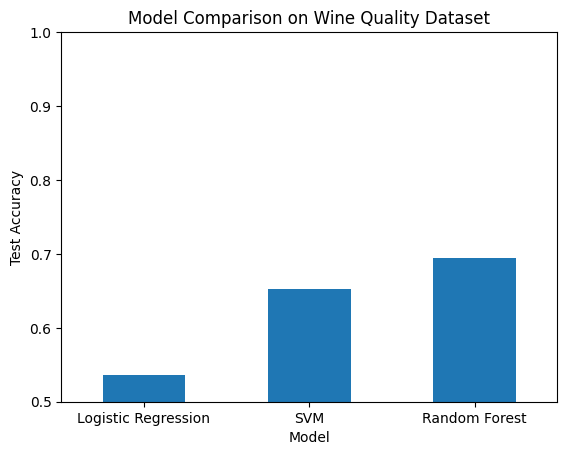

In [50]:
# Collect best accuracies for each classifier
logistic_results_3_best_accuracy = logistic_results_3_df['test_accuracy'].max()
svm_results_3_best_accuracy = svm_3_results_df['test_accuracy'].max()
rf_results_3_best_accuracy = rf_results_df_3['test_accuracy'].max()

# Create a comparison DataFrame
comparison_df_wine = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Random Forest'],
    'Best Test Accuracy': [logistic_results_3_best_accuracy, 
                           svm_results_3_best_accuracy, 
                           rf_results_3_best_accuracy]
})

# Display the comparison table
print("Comparison of Classifiers on Wine Dataset")
print(comparison_df_wine)

# Plot comparison as a bar chart
comparison_df_wine.plot(kind = 'bar', x = 'Model', y = 'Best Test Accuracy', legend = False)
plt.title("Model Comparison on Wine Quality Dataset")
plt.ylabel("Test Accuracy")
plt.xticks(rotation = 0)  
plt.ylim(0.5, 1.0)     
plt.show()

## Random Forest Feature Importance Heatmap for Wine Dataset

In [51]:
# Initialize results storage
rf_wine_results = []
feature_importances = {partition: [] for partition in partitions.keys()}

# Define Random Forest hyperparameter grid
rf_param_grid = {
    "n_estimators": [50, 100],   
    "max_depth": [None, 10, 20], 
    "criterion": ["gini", "entropy"]  
}

# Loop through partitions and trials
for partition_name, (X_train, X_test, y_train, y_test) in partitions.items():
    print(f"Partition: {partition_name}")
    
    for trial in range(3):
        print(f"  Trial {trial + 1}")

        # Initialize Random Forest Classifier
        rf = RandomForestClassifier(random_state = 42)
        rf.fit(X_train, y_train)  
        
        # Collect feature importances
        importance = rf.feature_importances_
        feature_importances[partition_name].append(importance)

        # Save results
        train_acc = accuracy_score(y_train, rf.predict(X_train))
        test_acc = accuracy_score(y_test, rf.predict(X_test))
        
        rf_wine_results.append({
            "partition": partition_name,
            "trial": trial + 1,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

# Average feature importances over trials
avg_feature_importances = {}
for partition, importances in feature_importances.items():
    avg_feature_importances[partition] = np.mean(importances, axis = 0)

# Convert to DataFrame
features = X_train.columns
heatmap_data = pd.DataFrame(avg_feature_importances, index = features)

Partition: 20/80
  Trial 1
  Trial 2
  Trial 3
Partition: 50/50
  Trial 1
  Trial 2
  Trial 3
Partition: 80/20
  Trial 1
  Trial 2
  Trial 3


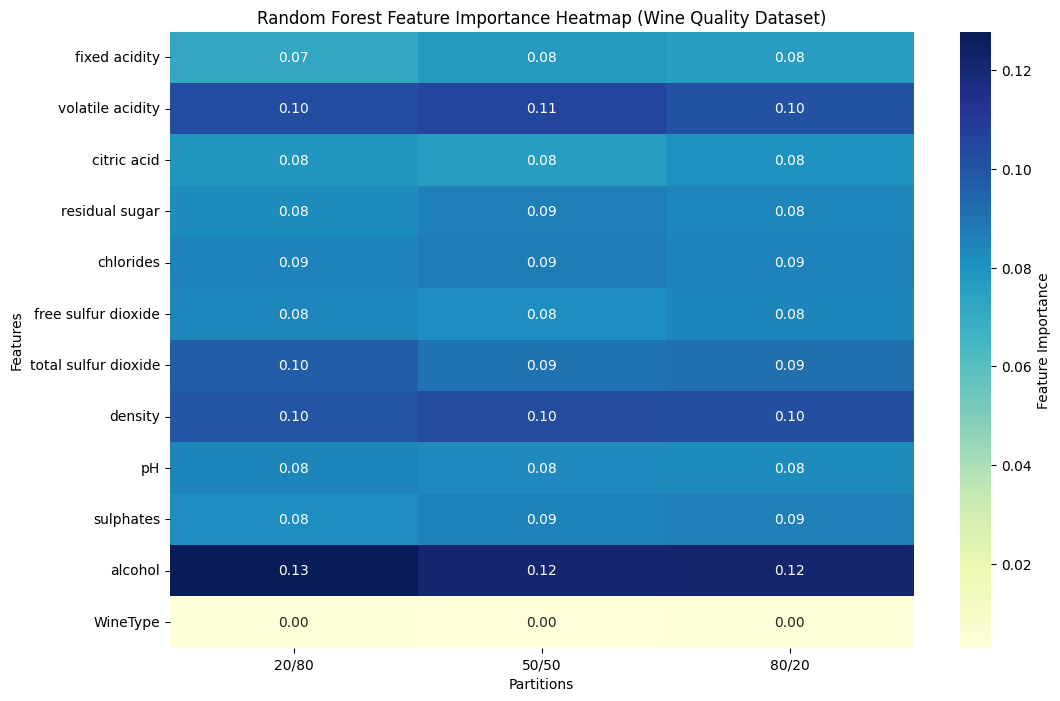

In [52]:
# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={'label': 'Feature Importance'})
plt.title("Random Forest Feature Importance Heatmap (Wine Quality Dataset)")
plt.xlabel("Partitions")
plt.ylabel("Features")
plt.show()